In [5]:
import sys

%pip install torch torchvision matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader

from torchvision import datasets
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

from sklearn.metrics import confusion_matrix, classification_report

In [7]:
train_data = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=ToTensor()
)

100%|██████████| 9.91M/9.91M [00:07<00:00, 1.34MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 106kB/s]
100%|██████████| 1.65M/1.65M [00:02<00:00, 748kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.68MB/s]


In [8]:
print("Training samples:", len(train_data))
print("Testing samples:", len(test_data))

Training samples: 60000
Testing samples: 10000


In [9]:
image, label = train_data[0]

print("Image shape:", image.shape)
print("Label:", label)

Image shape: torch.Size([1, 28, 28])
Label: 5


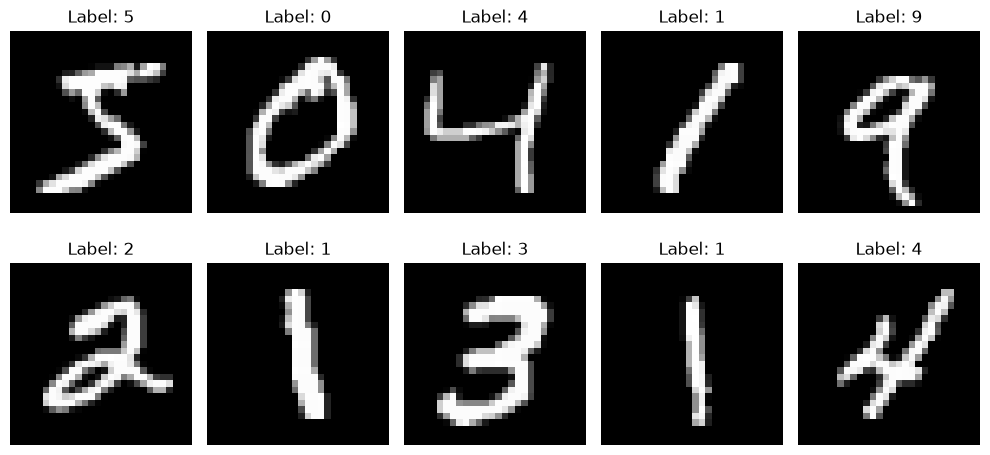

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    image, label = train_data[i]

    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [11]:
batch_size = 64

train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False
)

In [12]:
images, labels = next(iter(train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)

Images: torch.Size([64, 1, 28, 28])
Labels: torch.Size([64])


In [13]:
# Create CNN

In [17]:
class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv_layers = nn.Sequential(

            # 1 × 28 × 28
            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            
            # 32 × 28 × 28
            nn.MaxPool2d(kernel_size=2),

            # 32 × 14 × 14
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            # 64 × 14 × 14
            nn.MaxPool2d(kernel_size=2)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)

        return x

In [20]:
cnn_model = CNN().to(device)

print(cnn_model)

CNN(
  (conv_layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [21]:
criterion = nn.CrossEntropyLoss()

cnn_optimizer = optim.Adam(
    cnn_model.parameters(),
    lr=0.001
)

In [22]:
def train_model(model, loader, criterion, optimizer, epochs):
    train_losses = []
    train_accuracies = []
    for epoch in range(epochs):
        model.train()
        running_loss = 0
        correct = 0
        total = 0
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            # Statistics
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(loader)
        epoch_accuracy = 100 * correct / total

        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_accuracy)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {epoch_loss:.4f} "
            f"Accuracy: {epoch_accuracy:.2f}%"
        )

    return train_losses, train_accuracies

In [23]:
cnn_losses, cnn_accuracies = train_model(
    cnn_model,
    train_loader,
    criterion,
    cnn_optimizer,
    epochs=5
)

Epoch [1/5] Loss: 0.2328 Accuracy: 92.83%
Epoch [2/5] Loss: 0.0738 Accuracy: 97.82%
Epoch [3/5] Loss: 0.0539 Accuracy: 98.45%
Epoch [4/5] Loss: 0.0405 Accuracy: 98.73%
Epoch [5/5] Loss: 0.0343 Accuracy: 98.92%


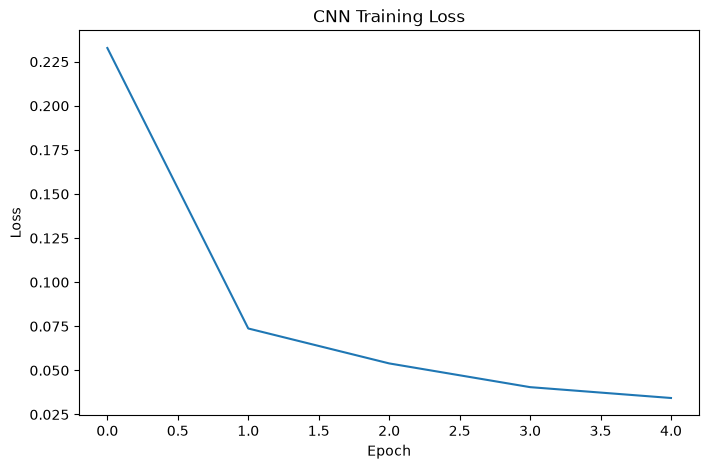

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(cnn_losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training Loss")

plt.show()

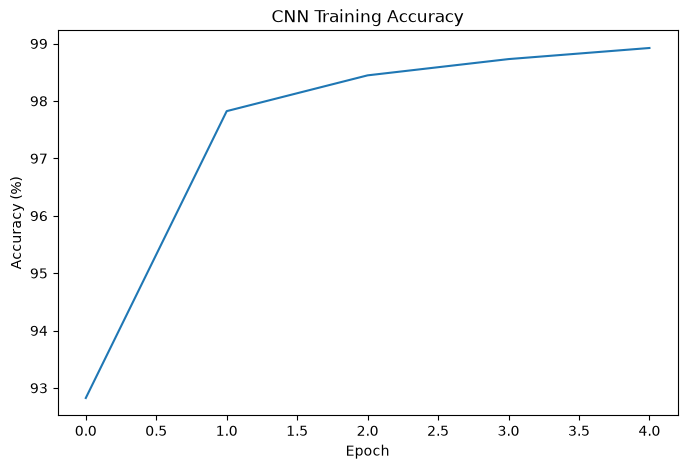

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(cnn_accuracies)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("CNN Training Accuracy")

plt.show()

In [26]:
def evaluate_model(model, loader):
    model.eval()
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_predictions.extend(
                predicted.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    accuracy = 100 * correct / total

    return accuracy, all_labels, all_predictions

In [27]:
cnn_accuracy, cnn_labels, cnn_predictions = evaluate_model(
    cnn_model,
    test_loader
)

print(f"CNN Test Accuracy: {cnn_accuracy:.2f}%")

CNN Test Accuracy: 99.08%


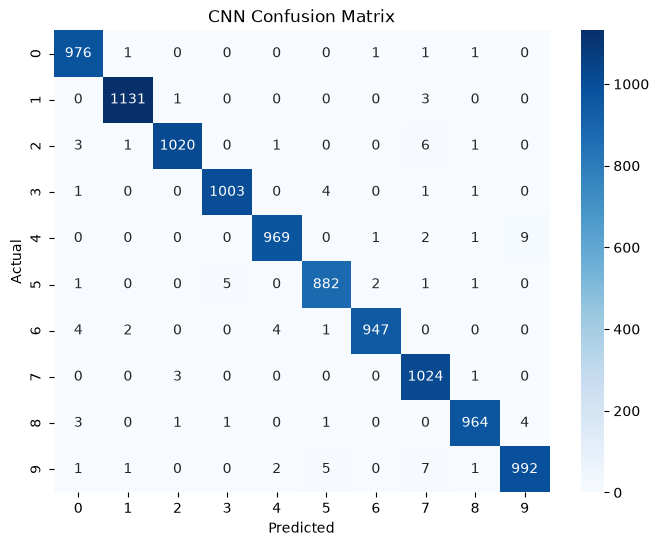

In [28]:
cnn_cm = confusion_matrix(
    cnn_labels,
    cnn_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cnn_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")

plt.show()